In [7]:
# library(knitr)
# knitr::opts_chunk$set(echo = TRUE)

## Regresja Poissonowska

In [8]:
# cyl ~ mpg + disp + hp + drat + wt + qsec

In [9]:
data(mtcars)
head(mtcars)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1


Jako zmienną objaśnianą wybieramy `cyl` i usuwamy pozostałe powiązane zmienne.

In [20]:
dt <- mtcars
dt <- dt[, c("cyl", "mpg", "disp", "hp", "drat", "wt", "qsec")]
head(dt)

,cyl,mpg,disp,hp,drat,wt,qsec
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,6,21.0,160,110,3.90,2.620,16.46
Mazda RX4 Wag,6,21.0,160,110,3.90,2.875,17.02
Datsun 710,4,22.8,108,93,3.85,2.320,18.61
Hornet 4 Drive,6,21.4,258,110,3.08,3.215,19.44
Hornet Sportabout,8,18.7,360,175,3.15,3.440,17.02
Valiant,6,18.1,225,105,2.76,3.460,20.22


Badamy wpływ predyktorów na liczbę 'cyl'

Przykładowe wykresy zależności pojedynczych zmiennych.

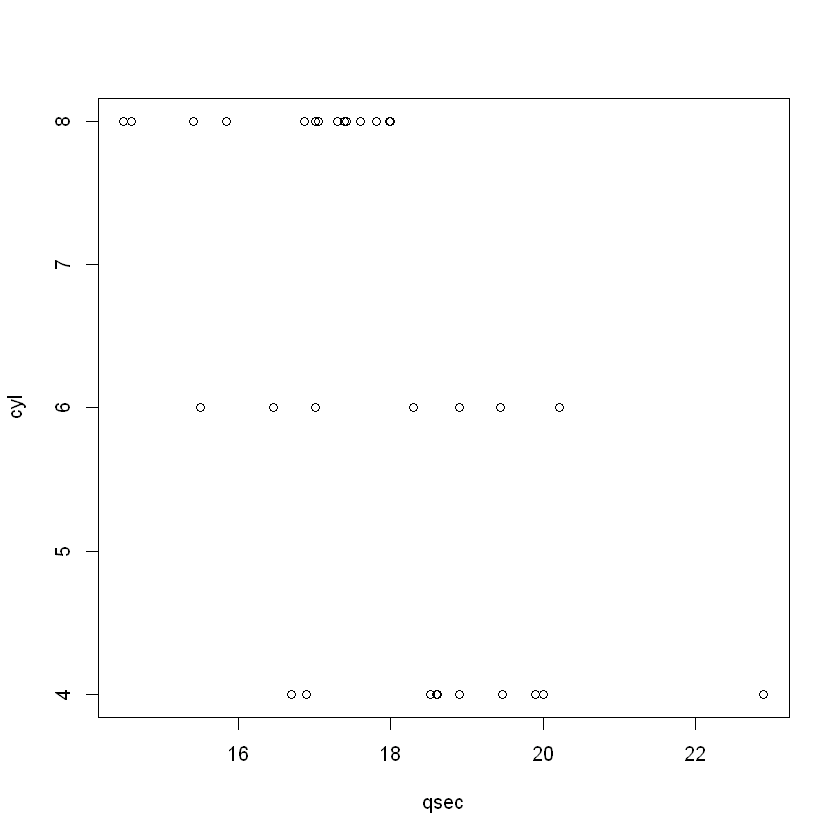

In [21]:
plot(cyl ~ qsec, data = dt)

Albo lepiej

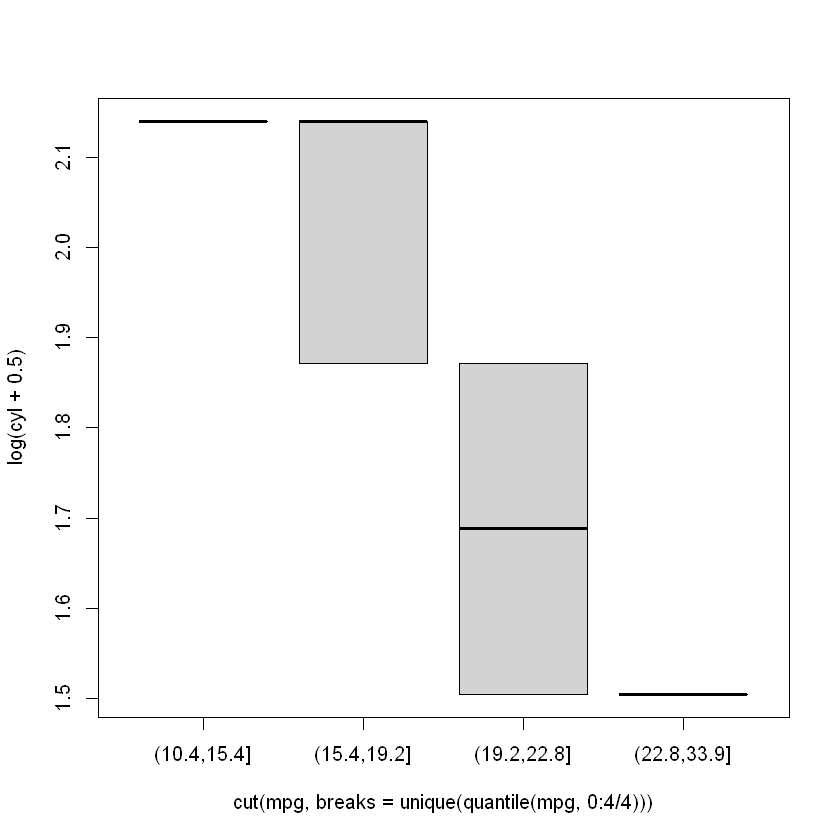

In [22]:
plot(log(cyl + 0.5) ~ cut(mpg, breaks = unique(quantile(mpg, 0:4/4))), data = dt)

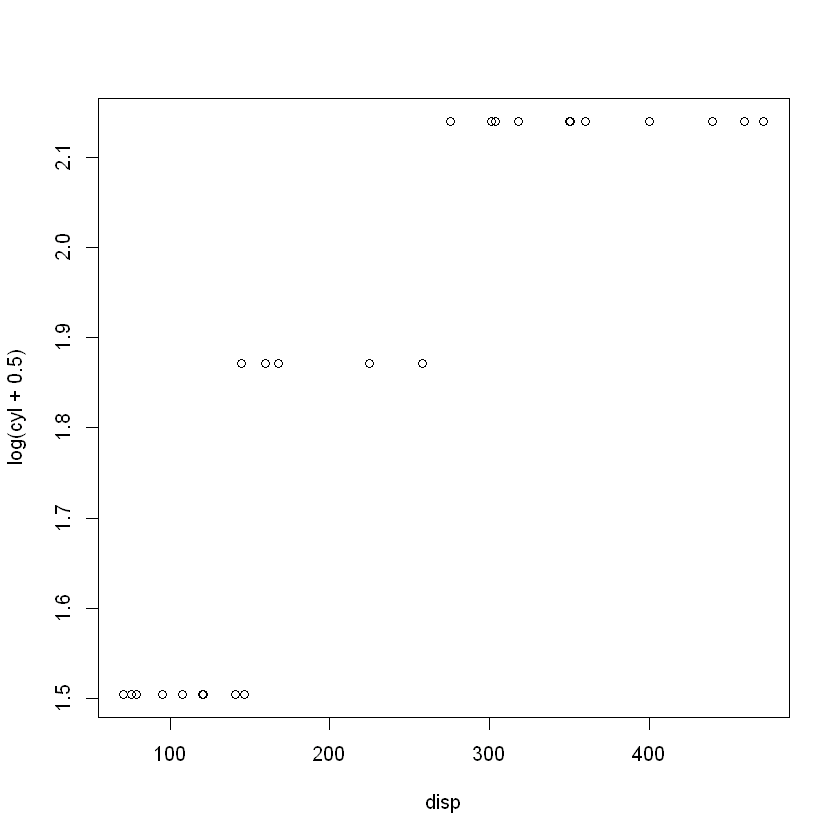

In [23]:
plot(log(cyl + 0.5) ~ disp, data = dt)

Wykres zwany spinogramem.

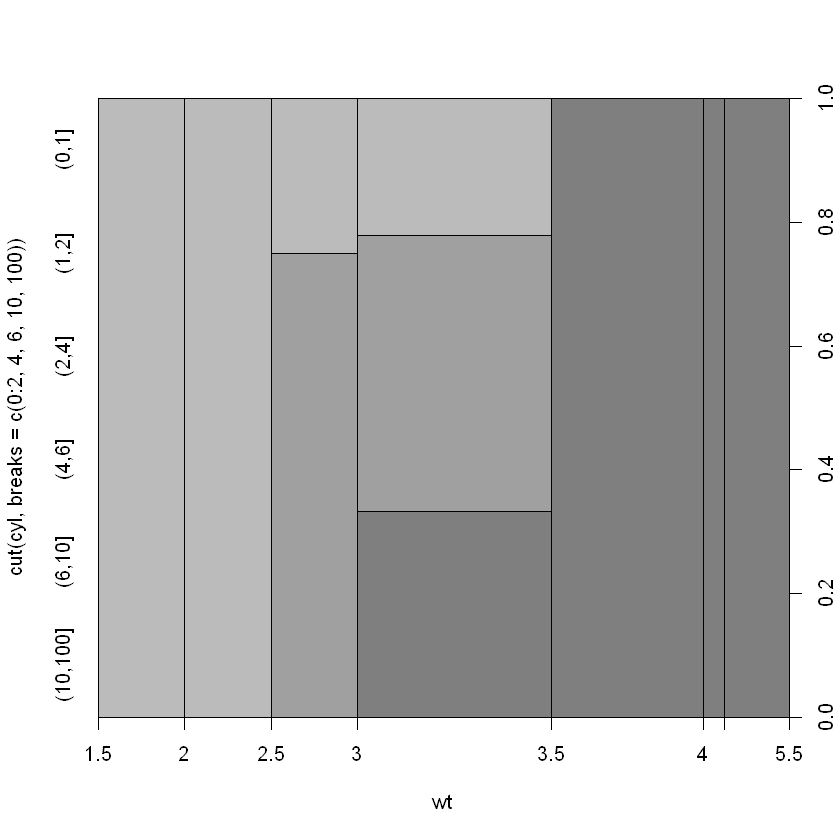

In [24]:
plot(cut(cyl, breaks = c(0:2, 4, 6, 10, 100)) ~ wt, data = dt, breaks = 9)

Budujemy pełny model regresji Poissonowskiej.

In [25]:
dt_fit <- glm(cyl ~ ., data = dt, family = poisson)
summary(dt_fit)


Call:
glm(formula = cyl ~ ., family = poisson, data = dt)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)  
(Intercept)  3.4342134  1.9024506   1.805   0.0711 .
mpg         -0.0130879  0.0327589  -0.400   0.6895  
disp         0.0006844  0.0017126   0.400   0.6894  
hp           0.0001098  0.0024344   0.045   0.9640  
drat        -0.1620819  0.2190058  -0.740   0.4593  
wt           0.0049626  0.2308977   0.021   0.9829  
qsec        -0.0557346  0.0832992  -0.669   0.5034  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 16.5743  on 31  degrees of freedom
Residual deviance:  1.7577  on 25  degrees of freedom
AIC: 132.42

Number of Fisher Scoring iterations: 4


### Model z napompowanymi zerami

W zbiorze danych jest znacząca liczba wierszy, dla których `ofp == 0`.

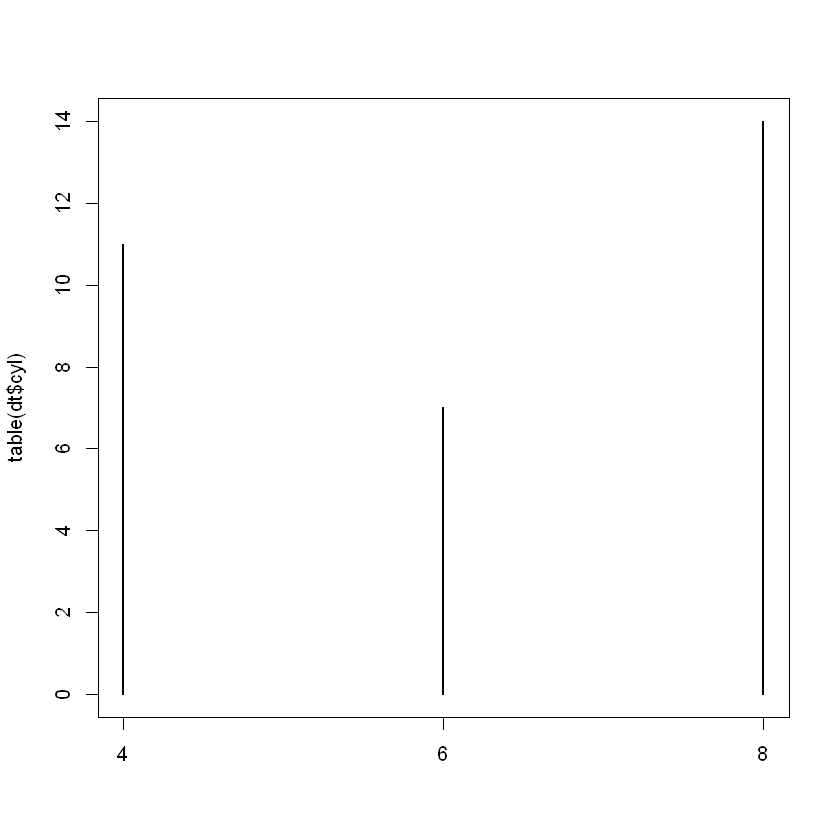

In [28]:
plot(table(dt$cyl))

Utrudnia to modelowanie przy pomocy rozkładu Poissona, w którym typowo
prawdopodobieństwo wartości 0 jest niskie. W związku z tym używa się
modeli rozbudowanych, które *pompują* prawdopodobieństwo zera. Jednym
z takich modeli jest **model Poissonowski z napompowanym zerem**
[*Zero-Inflated Poisson, ZIP*]. Jest to model miksturowy, w którym
funkcja prawdopodobieństwa (warunkowa) zmiennej odpowiedzi ma postać
$$
\begin{aligned}
  P(Y = 0) & = \pi_0 + (1 - \pi_0) e^{-\lambda}, & \\
  P(Y = k) & = (1 - \pi_0) \, e^{-\lambda} \frac{\lambda^k}{k!},
  & k = 1, 2, \dots
\end{aligned}
$$
Nie jest to GLM i wymaga nieco bardziej skomplikowanego treningu. Implementacja
modelu ZIP jest dostępna np. w pakiecie `pscl`.

In [29]:
library(pscl) |> suppressPackageStartupMessages()
dt_zip0_fit <- zeroinfl(cyl ~ ., data = dt)
summary(dt_zip0_fit)

Warning message:
"pakiet 'pscl' został zbudowany w wersji R 4.5.3"


ERROR: Error in zeroinfl(cyl ~ ., data = dt): invalid dependent variable, minimum count is not zero


Nie wszystkie predyktory okazały się istotne zarówno przy modelowaniu
części Poissonowskiej, jak i w modelowaniu $\pi_0$, stosujemy więc model
zredukowany

In [ ]:
# cyl ~ mpg + disp + hp + drat + wt + qsec

In [30]:
dt_zip_fit <- zeroinfl(
    cyl ~ . - disp - hp | drat,
    data = dt
)
summary(dt_zip_fit)

ERROR: Error in zeroinfl(cyl ~ . - disp - hp | drat, data = dt): invalid dependent variable, minimum count is not zero


In [31]:
data.frame(
  model = c("Poisson", "ZIP full", "ZIP"),
  logLik = vapply(list(dt_fit, dt_zip0_fit, dt_zip_fit), logLik, FUN.VALUE = double(1)),
  AIC = vapply(list(dt_fit, dt_zip0_fit, dt_zip_fit), AIC, FUN.VALUE = double(1))
)

ERROR: Error: nie znaleziono obiektu 'dt_zip0_fit'


### Zadanie

Powtórz powyższe analizy dla zbioru danych `PhdPubs` z pakietu `vcdExtra`.